SafeX Scam Detection - Kaggle-Ready Notebook Script
===================================================

- Designed to run inside Kaggle notebooks.
- Robust to different dataset folder names under /kaggle/input/.
- Fixes templating artifacts (double braces) from the original draft.

Author: Jonny's Workspace / Kimi Agent
Date: 2026-02-16

# SafeX Scam Detection (Kaggle-Ready)
This notebook builds a strong baseline scam detector using TF‑IDF + Logistic Regression.
It also exports model artifacts into `/kaggle/working/`.

**Tip:** If you get "could not load" messages, check that you attached the dataset and that the files exist in `/kaggle/input/`.

In [1]:
# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, 
    accuracy_score, precision_recall_curve
)
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

INPUT_ROOT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports complete")
if INPUT_ROOT.exists():
    print("📁 /kaggle/input contents:", [p.name for p in INPUT_ROOT.iterdir()])

✅ Imports complete
📁 /kaggle/input contents: ['datasets']


In [2]:
# ============================================================
# CELL 2: Configuration
# ============================================================
CONFIG = {
    "max_features": 40000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "test_size": 0.2,
    "random_state": RANDOM_SEED,
}

# Language normalization mapping
LANG_MAP = {
    "English": "en",
    "English (Malaysian Standard)": "en",
    "Bahasa Melayu": "ms",
    "Bahasa Melayu (Pasar/Slang)": "ms",
    "Bahasa Melayu (Formal - Govt/Bank style)": "ms",
    "Chinese": "zh",
    "Chinese (Simplified)": "zh",
    "Manglish": "manglish",
    "mixed": "mixed",
}

print("✅ Configuration loaded")

✅ Configuration loaded


In [3]:
# ============================================================
# CELL 3: Text Cleaning Functions
# ============================================================
def remove_code_fences(text: str) -> str:
    """Remove markdown code fences and inline code."""
    text = re.sub(r"```[\s\S]*?```", " ", text)
    text = re.sub(r"`[^`]*`", " ", text)
    return text

def remove_meta_lines(text: str) -> str:
    """Remove synthetic artifact lines (prompt/template metadata)."""
    meta_patterns = [
        r"^Tetapan:.*$", r"^Nada:.*$", r"^Konteks:.*$",
        r"^Teknik:.*$", r"^Platform:.*$", r"^Formatted as.*$",
        r"^AI [Dd]isclaimer.*$", r"^System prompt.*$"
    ]
    lines = str(text).split("\n")
    cleaned = [l for l in lines if not any(re.match(p, l.strip(), re.I) for p in meta_patterns)]
    return "\n".join(cleaned)

def normalize_obfuscation(text: str) -> str:
    """Normalize common obfuscation techniques."""
    text = re.sub(r"\b([A-Za-z])\.(?=[A-Za-z]\.)", r"\1", text)
    text = text.replace("\u200b", "").replace("\u200c", "").replace("\u200d", "")
    text = re.sub(r"W\.?h\.?a\.?t\.?s\.?A\.?p\.?p", "WhatsApp", text, flags=re.I)
    text = re.sub(r"L\.?i\.?n\.?k", "Link", text, flags=re.I)
    return text

def normalize_placeholders(text: str) -> str:
    """Normalize sensitive info to placeholders."""
    text = re.sub(r"https?://\S+", "<URL>", text)
    text = re.sub(r"www\.\S+", "<URL>", text)
    text = re.sub(r"\+?6?0[\d\-\s]{8,12}", "<PHONE>", text)
    text = re.sub(r"01[\d\-\s]{7,10}", "<PHONE>", text)
    text = re.sub(r"\S+@\S+\.\S+", "<EMAIL>", text)
    text = re.sub(r"RM[\s]*[\d,]+\.?\d*", "<RM_AMOUNT>", text)
    text = re.sub(r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}", "<DATE>", text)
    return text

def add_cjk_spacing(text: str) -> str:
    """Add spacing for CJK tokenization."""
    text = re.sub(r"([\u4e00-\u9fff])([^\u4e00-\u9fff])", r"\1 \2", text)
    text = re.sub(r"([^\u4e00-\u9fff])([\u4e00-\u9fff])", r"\1 \2", text)
    return text

def clean_text(text) -> str:
    """Full cleaning pipeline."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = remove_code_fences(text)
    text = remove_meta_lines(text)
    text = normalize_obfuscation(text)
    text = normalize_placeholders(text)
    text = add_cjk_spacing(text)
    text = " ".join(text.split())
    return text.strip()

def compute_derived_features(text: str) -> dict:
    """Compute boolean and numeric features."""
    t = text or ""
    tl = t.lower()

    features = {}
    features["has_url"] = "<URL>" in t or bool(re.search(r"https?://|www\.", t))
    features["has_phone"] = "<PHONE>" in t or bool(re.search(r"\b(?:01\d|60\d)\b", tl))
    features["has_money"] = "<RM_AMOUNT>" in t or bool(re.search(r"RM\s*\d", t))
    features["has_otp"] = bool(re.search(r"\b\d{4,6}\b.*?(?:tac|otp)", tl))
    features["has_han"] = bool(re.search(r"[\u4e00-\u9fff]", t))
    features["digit_count"] = sum(c.isdigit() for c in t)
    features["exclaim_count"] = t.count("!")

    urgency_kws = ["urgent", "segera", "cepat", "immediate", "now", "sekarang"]
    features["urgency_kw_count"] = sum(1 for kw in urgency_kws if kw in tl)
    return features

print("✅ Text cleaning functions defined")

✅ Text cleaning functions defined


In [4]:
# ============================================================
# CELL 4: Locate & Load Data (Robust for Kaggle)
# ============================================================
# Preferred file locations (edit if your dataset structure differs).
files = {
    "safex_v3": "/kaggle/input/safex/safex_comprehensive_50k_v3.csv",
    "safex_checkpoint": "/kaggle/input/safex/safex_comprehensive_50k_v3_checkpoint_50000.csv",
    "safex_seallm": "/kaggle/input/safex/safex_seallm_v3_1.5b_30k_checkpoint_50000.csv",
    "safex_perplexity": "/kaggle/input/safex/safex_perplexity_10k.csv",
    "benign": "/kaggle/input/safex/benign_50k.csv",
    "benign_seallm": "/kaggle/input/safex/benign_seallm_v3_50k.csv",
}

def resolve_path(p: str) -> Path | None:
    """Try exact path; else search for basename anywhere under /kaggle/input."""
    cand = Path(p)
    if cand.exists():
        return cand
    if not INPUT_ROOT.exists():
        return None
    basename = cand.name
    matches = list(INPUT_ROOT.rglob(basename))
    return matches[0] if matches else None

datasets = {}
resolved = {k: resolve_path(v) for k, v in files.items()}

for name, path in resolved.items():
    if path is None:
        print(f"⚠️  Could not find {name} (expected: {files[name]})")
        continue
    try:
        datasets[name] = pd.read_csv(path)
        print(f"✅ Loaded {name}: {len(datasets[name]):,} rows   ({path})")
    except Exception as e:
        print(f"❌ Failed to load {name} from {path}: {e}")

if not datasets:
    raise RuntimeError(
        "No datasets loaded. Attach the SafeX dataset to this Kaggle notebook "
        "and ensure CSV files exist under /kaggle/input/."
    )

✅ Loaded safex_v3: 22,096 rows   (/kaggle/input/datasets/jonnyng88/synthetic/safex_comprehensive_50k_v3.csv)
✅ Loaded safex_checkpoint: 35,327 rows   (/kaggle/input/datasets/jonnyng88/synthetic/safex_comprehensive_50k_v3_checkpoint_50000.csv)
✅ Loaded safex_seallm: 31,733 rows   (/kaggle/input/datasets/jonnyng88/synthetic/safex_seallm_v3_1.5b_30k_checkpoint_50000.csv)
✅ Loaded safex_perplexity: 3,660 rows   (/kaggle/input/datasets/jonnyng88/synthetic/safex_perplexity_10k.csv)
✅ Loaded benign: 41,144 rows   (/kaggle/input/datasets/jonnyng88/synthetic/benign_50k.csv)
✅ Loaded benign_seallm: 29,305 rows   (/kaggle/input/datasets/jonnyng88/synthetic/benign_seallm_v3_50k.csv)


In [5]:
# ============================================================
# CELL 5: Preprocess & Merge
# ============================================================
def normalize_dataset(df: pd.DataFrame, is_scam: bool, source_name: str) -> pd.DataFrame:
    """Normalize a dataset to a unified schema."""
    df = df.copy()
    df["y"] = 1 if is_scam else 0
    df["label_str"] = "scam" if is_scam else "benign"
    df["source_name"] = source_name

    # Pick text column
    if "text" not in df.columns:
        # Try common fallbacks
        for alt in ["message", "content", "body"]:
            if alt in df.columns:
                df["text"] = df[alt]
                break
    if "text" not in df.columns:
        raise ValueError(f"[{source_name}] Missing a text column (expected 'text'). Columns: {list(df.columns)[:30]}")

    # Normalize message type
    type_candidates = ["scam_type", "benign_type", "category", "type"]
    type_col = next((c for c in type_candidates if c in df.columns), None)
    df["message_type"] = df[type_col] if type_col else "unknown"

    # Normalize language
    if "language" in df.columns:
        lang = df["language"].astype(str).map(LANG_MAP).fillna("other")
    else:
        lang = pd.Series(["unknown"] * len(df), index=df.index)
    df["language"] = lang

    # Clean text
    df["text_clean"] = df["text"].apply(clean_text)
    df = df[df["text_clean"].str.len() > 0].copy()

    # Derived features
    derived_df = df["text_clean"].apply(compute_derived_features).apply(pd.Series)
    df = pd.concat([df.reset_index(drop=True), derived_df.reset_index(drop=True)], axis=1)

    # Select columns
    cols = [
        "text_clean", "y", "label_str", "message_type", "language",
        "has_url", "has_phone", "has_money", "has_otp", "has_han",
        "digit_count", "exclaim_count", "urgency_kw_count",
    ]
    return df[[c for c in cols if c in df.columns]]

cleaned = []
for name, df in datasets.items():
    is_scam = name.startswith("safex")
    cleaned.append(normalize_dataset(df, is_scam=is_scam, source_name=name))

master_df = pd.concat(cleaned, ignore_index=True)

# Final schema
master_df.rename(columns={"text_clean": "text"}, inplace=True)

# Deduplication (keep first seen)
master_df["text_key"] = master_df["text"].str.lower().str.replace(r"\s+", "", regex=True)
master_df = master_df.drop_duplicates(subset=["text_key"], keep="first").drop(columns=["text_key"])

print(f"✅ Final dataset: {len(master_df):,} rows")
print("✅ Label distribution:\n", master_df["y"].value_counts())

✅ Final dataset: 147,725 rows
✅ Label distribution:
 y
1    87002
0    60723
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 6: Train/Test Split (Text + Numeric Features)
# ============================================================
numeric_cols = [
    "has_url", "has_phone", "has_money", "has_otp", "has_han",
    "digit_count", "exclaim_count", "urgency_kw_count",
]
for c in numeric_cols:
    if c not in master_df.columns:
        master_df[c] = 0

X_text = master_df["text"].astype(str).values
X_num = master_df[numeric_cols].copy()
# Ensure numeric dtypes
for c in numeric_cols:
    if X_num[c].dtype == bool:
        X_num[c] = X_num[c].astype(int)
X_num = X_num.fillna(0)

y = master_df["y"].values

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["random_state"],
)

print(f"✅ Train: {len(X_text_train):,}, Test: {len(X_text_test):,}")

✅ Train: 118,180, Test: 29,545


In [7]:
# ============================================================
# CELL 7: Train Model (TF‑IDF + numeric features)
# ============================================================
tfidf = TfidfVectorizer(
    ngram_range=CONFIG["ngram_range"],
    max_features=CONFIG["max_features"],
    min_df=CONFIG["min_df"],
    max_df=CONFIG["max_df"],
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)

# Scale numeric features (sparse-safe)
scaler = StandardScaler(with_mean=False)
X_num_train_s = scaler.fit_transform(csr_matrix(X_num_train.values))
X_num_test_s = scaler.transform(csr_matrix(X_num_test.values))

X_train = hstack([X_train_tfidf, X_num_train_s]).tocsr()
X_test = hstack([X_test_tfidf, X_num_test_s]).tocsr()

clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(f"\nAUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1:  {f1_score(y_test, y_pred):.4f}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Scam"]))


AUC: 0.9862
F1:  0.9436
Acc: 0.9345

Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      0.94      0.92     12145
        Scam       0.96      0.93      0.94     17400

    accuracy                           0.93     29545
   macro avg       0.93      0.94      0.93     29545
weighted avg       0.94      0.93      0.93     29545



In [8]:
# ============================================================
# CELL 8: Threshold Analysis
# ============================================================
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = int(np.argmax(f1_scores[:-1]))  # last point has no threshold

mid_threshold = float(thresholds[best_idx])
high_threshold = 0.7

print(f"✅ Optimal mid threshold: {mid_threshold:.3f} (F1={float(f1_scores[best_idx]):.4f})")
print("\n3‑Band Policy:")
print(f"  HIGH (≥{high_threshold}): Strong warn")
print(f"  MID  ({mid_threshold:.3f}–{high_threshold}): Suspicious")
print(f"  LOW  (<{mid_threshold:.3f}): No warn")

✅ Optimal mid threshold: 0.463 (F1=0.9467)

3‑Band Policy:
  HIGH (≥0.7): Strong warn
  MID  (0.463–0.7): Suspicious
  LOW  (<0.463): No warn


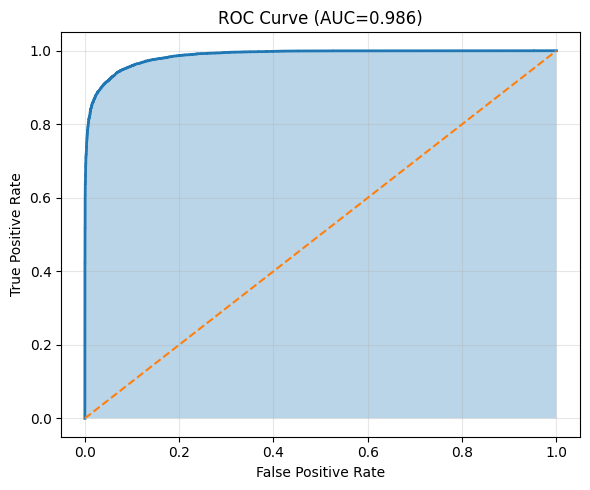

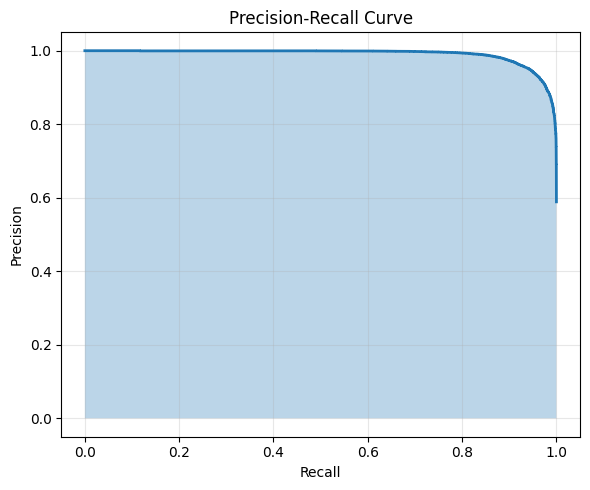

In [9]:
# ============================================================
# CELL 9: Visualizations (saved to /kaggle/working)
# ============================================================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.fill_between(fpr, tpr, alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC={roc_auc_score(y_test, y_prob):.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(WORKING_DIR / "safex_roc.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2)
plt.fill_between(recalls, precisions, alpha=0.3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision‑Recall Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(WORKING_DIR / "safex_pr.png", dpi=150)
plt.show()

In [10]:
# ============================================================
# CELL 10: Export Model Artifacts (to /kaggle/working)
# ============================================================
# Save TF-IDF vocab + idf, classifier weights, numeric scaler, and thresholds.
vocab = {k: int(v) for k, v in tfidf.vocabulary_.items()}
with open(WORKING_DIR / "tfidf_vocab.json", "w") as f:
    json.dump(vocab, f)

with open(WORKING_DIR / "tfidf_idf.json", "w") as f:
    json.dump(tfidf.idf_.tolist(), f)

np.save(WORKING_DIR / "model_coef.npy", clf.coef_[0])
np.save(WORKING_DIR / "model_intercept.npy", clf.intercept_)

# Store scaler params (so inference reproduces exact feature scaling)
scaler_state = {
    "with_mean": scaler.with_mean,
    "with_std": scaler.with_std,
    "scale_": getattr(scaler, "scale_", None).tolist() if getattr(scaler, "scale_", None) is not None else None,
}
with open(WORKING_DIR / "numeric_scaler.json", "w") as f:
    json.dump(scaler_state, f)

thresholds_config = {"mid": mid_threshold, "high": float(high_threshold)}
with open(WORKING_DIR / "thresholds.json", "w") as f:
    json.dump(thresholds_config, f)

print("✅ Model artifacts exported to /kaggle/working")

✅ Model artifacts exported to /kaggle/working


## Optional: Create a submission.csv (if a test set exists)
If your Kaggle competition provides a test file, set `TEST_PATH` below (or leave it as None to auto-detect).

In [11]:
TEST_PATH = None  # e.g. "/kaggle/input/safex/test.csv" or "/kaggle/input/<your-dataset>/test.csv"

def autodetect_test_csv() -> Path | None:
    if not INPUT_ROOT.exists():
        return None
    candidates = []
    for p in INPUT_ROOT.rglob("*.csv"):
        name = p.name.lower()
        if "test" in name and "train" not in name:
            candidates.append(p)
    # Prefer the shortest path (usually the actual competition file)
    candidates.sort(key=lambda x: (len(str(x)), str(x)))
    return candidates[0] if candidates else None

test_path = Path(TEST_PATH) if TEST_PATH else autodetect_test_csv()
if test_path and test_path.exists():
    test_df = pd.read_csv(test_path)
    if "text" not in test_df.columns:
        print(f"⚠️ Found test file but no 'text' column: {test_path} (cols={list(test_df.columns)[:20]})")
    else:
        test_text = test_df["text"].astype(str).apply(clean_text).values

        # Derived numeric features for test
        test_num = test_df["text"].astype(str).apply(clean_text).apply(compute_derived_features).apply(pd.Series)
        for c in numeric_cols:
            if c not in test_num.columns:
                test_num[c] = 0
        for c in numeric_cols:
            if test_num[c].dtype == bool:
                test_num[c] = test_num[c].astype(int)
        test_num = test_num[numeric_cols].fillna(0)

        X_test_tfidf_full = tfidf.transform(test_text)
        X_test_num_full = scaler.transform(csr_matrix(test_num.values))
        X_test_full = hstack([X_test_tfidf_full, X_test_num_full]).tocsr()

        test_prob = clf.predict_proba(X_test_full)[:, 1]

        # Build submission
        id_col = None
        for cand in ["id", "ID", "Id", "message_id"]:
            if cand in test_df.columns:
                id_col = cand
                break

        sub = pd.DataFrame({
            "id": test_df[id_col] if id_col else np.arange(len(test_df)),
            "label": test_prob
        })
        sub_path = WORKING_DIR / "submission.csv"
        sub.to_csv(sub_path, index=False)
        print(f"✅ Wrote submission: {sub_path}")
else:
    print("ℹ️ No test CSV auto-detected. If you have one, set TEST_PATH to its location.")

ℹ️ No test CSV auto-detected. If you have one, set TEST_PATH to its location.


In [13]:
# ============================================================
# CELL X: Manual test set (benign + scam) + metrics (FIXED)
# Uses TF-IDF + numeric derived features (matches training)
# ============================================================

import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from IPython.display import display

# --- Your samples (keep yours as-is) ---
USER_TEST_SAMPLES = [
    # BENIGN examples (5)
    ("Abang, dah sampai rumah? Mak tanya bila nak balik kampung cuti CNY.", 0),
    ("TnG notification: RM8.50 toll PLUS Highway deducted successfully.", 0),
    ("Selamat pagi! Meeting dengan client postpone ke Rabu pukul 10. Confirm ok?", 0),
    ("Lazada: Your order #MY20260215ABC will arrive tomorrow. Track in app.", 0),
    ("KWSP reminder: Kini anda boleh semak baki i-Akaun melalui portal rasmi kwsp.gov.my", 0),

    # SCAM examples (5)
    ("Kerja mudah! Tolong klik produk Shopee untuk tingkatkan sales, dapat komisen RM50-500 sehari. Add WhatsApp <PHONE> sekarang.", 1),
    ("KWSP: Pengeluaran khas RM10,000 telah diluluskan. Klik <URL> dan masukkan TAC <OTP> untuk proses.", 1),
    ("TM Bonus Hadiah Keluarga: Tahniah! Anda menang RM8,888 tunai. Claim di <URL> dalam 24 jam.", 1),
    ("Darling I miss you so much. Custom officer need release fee <RM_AMOUNT> for my gift to you. Urgent please.", 1),
    ("Bank Negara alert: Your account show suspicious transaction. Click <URL> immediately to prevent block.", 1),
]

BENIGN_TEST_SAMPLES = [
    ("Bro, nanti jumpa mamak pukul 9 boleh? Aku sampai lambat sikit.", 0),
    ("Hi, your Shopee order has been shipped. Rider akan hubungi bila dekat.", 0),
    ("Maybank: RM35.20 debit card purchase at MYDIN. If not you, call official hotline.", 0),
    ("Assalamualaikum, mesyuarat group assignment esok 3pm kat library ya.", 0),
    ("Grab: Your driver is arriving in 2 minutes. Please be ready at pickup point.", 0),
    ("Hi dear, I already transferred the rent just now. Please check when free.", 0),
    ("Poslaju: Parcel out for delivery today. Sila pastikan ada orang terima.", 0),
    ("老师提醒：明天带作业来学校，记得准时到。", 0),
    ("Touch 'n Go eWallet: Reload successful RM20.00. Thank you.", 0),
    ("Team, jangan lupa submit slide sebelum 11 malam. Thanks!", 0),
]

SCAM_TEST_SAMPLES = [
    ("Refund gagal diproses. Sila klik <URL> dan masukkan OTP <OTP> untuk tuntutan segera.", 1),
    ("Your account will be suspended today. Verify now at <URL> and enter TAC <OTP>.", 1),
    ("Kerajaan bagi bantuan RM200. Klik <URL> untuk kemaskini bank dan sahkan OTP <OTP> sekarang.", 1),
    ("Tahniah! Anda menang <RM_AMOUNT>. Claim hadiah di <URL> dan bayar yuran proses sekarang.", 1),
    ("Hi boss, saya HR. Kerja part time easy, sehari boleh dapat RM300. WhatsApp <PHONE> untuk mula.", 1),
    ("包裹被扣留，请点击 <URL> 支付关税，否则将退回。", 1),
    ("Sayang, kastam tahan hadiah. Mereka minta caj pelepasan <RM_AMOUNT>. Transfer ke <BANK_NAME> ya.", 1),
    ("Investment syariah compliant, confirm untung 5% sehari. Join group <URL> sekarang.", 1),
    ("Bank alert: suspicious login detected. Verify identity at <URL> or account will be frozen.", 1),
    ("Need urgent help—please send OTP <OTP> to confirm delivery, then parcel will release.", 1),
]

# --- Combine samples ---
eval_samples = USER_TEST_SAMPLES + BENIGN_TEST_SAMPLES + SCAM_TEST_SAMPLES
df_eval = pd.DataFrame(eval_samples, columns=["text_raw", "y_true"])

print("Eval set size:", len(df_eval))
print("Label counts:\n", df_eval["y_true"].value_counts())

# --- Ensure the numeric feature list matches training ---
try:
    numeric_cols
except NameError:
    numeric_cols = [
        "has_url", "has_phone", "has_money", "has_otp", "has_han",
        "digit_count", "exclaim_count", "urgency_kw_count",
    ]

# --- Featurize EXACTLY like training: TF-IDF + scaled numeric features ---
df_eval["text_clean"] = df_eval["text_raw"].astype(str).apply(clean_text)

num_df = df_eval["text_clean"].apply(compute_derived_features).apply(pd.Series)

# Guarantee all columns exist, correct order, correct dtypes
for c in numeric_cols:
    if c not in num_df.columns:
        num_df[c] = 0
num_df = num_df[numeric_cols].fillna(0)

for c in numeric_cols:
    if num_df[c].dtype == bool:
        num_df[c] = num_df[c].astype(int)

X_tfidf = tfidf.transform(df_eval["text_clean"].values)
X_num = csr_matrix(num_df.values)
X_num_s = scaler.transform(X_num)  # IMPORTANT: use the fitted scaler from training
X_eval = hstack([X_tfidf, X_num_s]).tocsr()

# Sanity check (should match 40008)
print("X_eval features:", X_eval.shape[1], "| clf expects:", getattr(clf, "n_features_in_", "unknown"))

# --- Predict probabilities ---
df_eval["prob_scam"] = clf.predict_proba(X_eval)[:, 1]

# --- Thresholds (use the ones computed earlier; fallback if missing) ---
mid = float(globals().get("mid_threshold", 0.5))
high = float(globals().get("high_threshold", 0.7))

df_eval["pred_mid"] = (df_eval["prob_scam"] >= mid).astype(int)
df_eval["band"] = df_eval["prob_scam"].apply(lambda p: "HIGH" if p >= high else ("MID" if p >= mid else "LOW"))

# --- Metrics ---
acc = accuracy_score(df_eval["y_true"], df_eval["pred_mid"])
f1 = f1_score(df_eval["y_true"], df_eval["pred_mid"])

print("\n=== Manual Eval Metrics (MID policy) ===")
print("mid_threshold:", round(mid, 4), "| high_threshold:", round(high, 4))
print("Accuracy:", round(acc, 4))
print("F1:", round(f1, 4))
print("Confusion matrix:\n", confusion_matrix(df_eval["y_true"], df_eval["pred_mid"]))
print(classification_report(df_eval["y_true"], df_eval["pred_mid"], target_names=["Benign", "Scam"]))

# --- Show errors first ---
df_eval["correct"] = (df_eval["pred_mid"] == df_eval["y_true"])
print("\nWrong predictions:", int((~df_eval["correct"]).sum()))

display(
    df_eval.sort_values(["correct", "prob_scam"], ascending=[True, False])[
        ["y_true", "pred_mid", "prob_scam", "band", "correct", "text_raw"]
    ].head(30)
)


Eval set size: 30
Label counts:
 y_true
0    15
1    15
Name: count, dtype: int64
X_eval features: 40008 | clf expects: 40008

=== Manual Eval Metrics (MID policy) ===
mid_threshold: 0.4626 | high_threshold: 0.7
Accuracy: 0.8
F1: 0.8333
Confusion matrix:
 [[ 9  6]
 [ 0 15]]
              precision    recall  f1-score   support

      Benign       1.00      0.60      0.75        15
        Scam       0.71      1.00      0.83        15

    accuracy                           0.80        30
   macro avg       0.86      0.80      0.79        30
weighted avg       0.86      0.80      0.79        30


Wrong predictions: 6


,y_true,pred_mid,prob_scam,band,correct,text_raw
13,0,1,0.763607,HIGH,False,"Assalamualaikum, mesyuarat group assignment es..."
0,0,1,0.690293,MID,False,"Abang, dah sampai rumah? Mak tanya bila nak ba..."
17,0,1,0.680973,MID,False,老师提醒：明天带作业来学校，记得准时到。
10,0,1,0.570447,MID,False,"Bro, nanti jumpa mamak pukul 9 boleh? Aku samp..."
4,0,1,0.541800,MID,False,KWSP reminder: Kini anda boleh semak baki i-Ak...
3,0,1,0.477789,MID,False,Lazada: Your order #MY20260215ABC will arrive ...
27,1,1,0.993390,HIGH,True,"Investment syariah compliant, confirm untung 5..."
8,1,1,0.992316,HIGH,True,Darling I miss you so much. Custom officer nee...
20,1,1,0.972907,HIGH,True,Refund gagal diproses. Sila klik <URL> dan mas...
24,1,1,0.971724,HIGH,True,"Hi boss, saya HR. Kerja part time easy, sehari..."
